# py-flexplot Examples: flex_nn + bluepill

This notebook walks through the two new modules shipped in v0.2.0:

- `pyflexplot.flex_nn` wraps a fitted neural network so it can be used in `compare_fits()` alongside statsmodels fits, and exposes column-shuffling variable importance.

- `pyflexplot.bluepill` generates clustered synthetic mixed-model data for teaching and demos.

## 1. Imports and seed

In [1]:
import numpy as np
import pandas as pd
import torch
import statsmodels.formula.api as smf
from pyflexplot import (
    flexplot,
    compare_fits,
    estimate_sd,
    mixed_model,
)
from pyflexplot.flex_nn import (
    NeuralNetFit,
    set_response_var,
    prepare_torch_data,
    permutation_importance,
)
np.random.seed(42)
torch.manual_seed(42)

## 2. Build a small regression dataset

In [2]:
rng = np.random.default_rng(0)
n = 200
X = rng.normal(size=(n, 3))
y = 1.5 * X[:, 0] - 2.0 * X[:, 1] + 0.7 * X[:, 2] + rng.normal(scale=0.2, size=n)
df = pd.DataFrame(X, columns=['x1', 'x2', 'x3'])
df['y'] = y
df.head()

,x1,x2,x3,y
0,0.125730,-0.132105,0.640423,0.669735
1,0.104900,-0.535669,0.361595,1.208830
2,1.304000,0.947081,-0.703735,-0.477022
3,-1.265421,-0.623274,0.041326,-0.167155
4,-2.325031,-0.218792,-1.245911,-3.866592


## 3. Fit a baseline OLS

In [3]:
ols = smf.ols('y ~ x1 + x2 + x3', data=df).fit()
ols.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.994
Model:                            OLS   Adj. R-squared:                  0.994
Method:                 Least Squares   F-statistic:                 1.104e+04
Date:                Fri, 28 Aug 2026   Prob (F-statistic):          3.03e-218
Time:                        07:20:20   Log-Likelihood:                 38.084
No. Observations:                 200   AIC:                            -68.17
Df Residuals:                     196   BIC:                            -54.97
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.0072      0.014     -0.504      0.615      -0.036       0.021
x1             1.4820      0.014    104.680      0.000       1.454       1.510
x2            -2.0192      0.014   -141.042      0.000      -2.047      -1.991
x3             0.7106      0.015     48.246      0.000       0.682       0.740
==============================================================================
Omnibus:                        0.827   Durbin-Watson:                   1.973
Prob(Omnibus):                  0.661   Jarque-Bera (JB):                0.894
Skew:                           0.049   Prob(JB):                        0.640
Kurtosis:                       2.687   Cond. No.                         1.14
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## 4. Fit a tiny neural network

In [4]:
X_t = torch.as_tensor(X, dtype=torch.float32)
y_t = torch.as_tensor(y, dtype=torch.float32)
model = torch.nn.Sequential(
    torch.nn.Linear(3, 8),
    torch.nn.ReLU(),
    torch.nn.Linear(8, 1),
).eval()
optim = torch.optim.Adam(model.parameters(), lr=0.05)
for epoch in range(500):
    optim.zero_grad()
    loss = torch.nn.functional.mse_loss(model(X_t).squeeze(-1), y_t)
    loss.backward()
    optim.step()
print(f'Final loss: {loss.item():.4f}')

Final loss: 0.0383


## 5. Wrap the network as a NeuralNetFit

In [5]:
set_response_var(model, 'y')
fit = NeuralNetFit(
    model=model,
    response_var='y',
    predictor_names=['x1', 'x2', 'x3'],
)
fit

NeuralNetFit(backend='torch', response='y', params=41, predictors=3)

`NeuralNetFit.predict(data)` returns a pandas Series aligned to `data.index`, matching what statsmodels produces. That alignment is what lets the existing `compare_fits()` machinery treat it as a drop-in fit.

In [6]:
pred = fit.predict(df)
print(type(pred), len(pred), pred.index.equals(df.index))
pred.head()

<class 'pandas.core.series.Series'> 200 True


0    0.900268
1    1.486245
2   -0.471074
3   -0.606734
4   -3.843079
Name: y__pred, dtype: float32

## 6. Compare OLS vs neural net

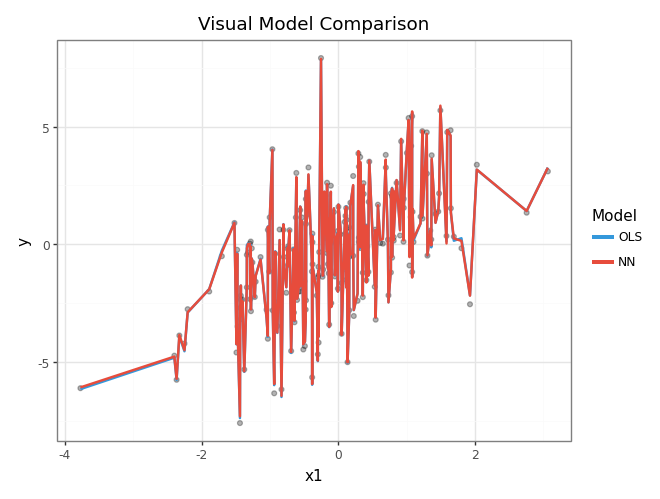

In [7]:
p = compare_fits('y ~ x1', data=df, model1=ols, model2=fit, labels=['OLS', 'NN'])
p.draw()

## 7. Variable importance via permutation

In [8]:
result = permutation_importance(
    fit, X=df[['x1', 'x2', 'x3']], y=df['y'],
    metric='mse', random_state=0,
)
result

,variable,importance
0,x2,7.062774
1,x1,5.165739
2,x3,0.898005


Higher `importance` means more important -- a unit is the change in MSE caused by shuffling that column. `x1` dominates because we set its true coefficient to 1.5, and `x3` matters least with coefficient 0.7.

## 8. prepare_torch_data: DataFrame to matrix

In [9]:
raw = pd.DataFrame({
    'x1': [1.0, 2.0, 3.0],
    'x2': [4.0, 5.0, 6.0],
    'color': pd.Categorical(['red', 'blue', 'red']),
})
matrix = prepare_torch_data(raw, categorical_vars=['color'])
matrix

array([[1., 4., 1.],
       [2., 5., 0.],
       [3., 6., 1.]])

Categoricals are integer-encoded (pd.Categorical sorts levels; here blue=0, red=1). Missing values raise -- imputation is the caller's job.

## 9. Synthetic data with bluepill.mixed_model

In [10]:
estimate_sd(10, 5, 15, num_sds=3)

1.6666666666666667

In [11]:
df_sim = mixed_model(
    fixed=[0.0, 0.2, 0.5, 0.3, 0.2],
    random=[0.1, 0.1, 0.0, 0.2, 0.1],
    sigma=0.3,
    clusters=15,
    n_per=[11, 3],
    vars={
        'depression': (10.0, 3.0, 0),
        'stress': (22.0, 7.0, 0),
        'life_events': ['no', 'yes'],
        'parental_depression': ['no', 'mild', 'moderate', 'severe'],
        'ses': (55.0, 15.0, 0),
        'therapist': [f'Dr. {chr(65 + i)}' for i in range(15)],
    },
    seed=42,
)
df_sim.head()

,therapist,depression,stress,life_events,parental_depression,ses
0,Dr. A,12.0,22.0,no,moderate,55.0
1,Dr. A,11.0,22.0,yes,mild,55.0
2,Dr. A,12.0,22.0,no,moderate,55.0
3,Dr. A,12.0,22.0,yes,no,55.0
4,Dr. A,10.0,22.0,no,mild,55.0


In [12]:
df_sim.dtypes

therapist               object
depression             float64
stress                 float64
life_events             object
parental_depression     object
ses                    float64
dtype: object

In [13]:
df_sim.describe()

,depression,stress,ses
count,163.000000,163.000000,163.0
mean,10.036810,21.944785,55.0
std,3.050783,7.097427,0.0
min,1.000000,5.000000,55.0
25%,8.000000,19.500000,55.0
50%,10.000000,22.000000,55.0
75%,12.000000,26.000000,55.0
max,18.000000,33.000000,55.0


## 10. Inspect the ground truth vs OLS recovery

In [14]:
m = smf.ols(
    'depression ~ stress + C(life_events) + C(parental_depression) + ses',
    data=df_sim,
).fit()
print(m.params)

Intercept                             0.000451
C(life_events)[T.yes]                 0.986422
C(parental_depression)[T.moderate]    1.539267
C(parental_depression)[T.no]          0.055802
C(parental_depression)[T.severe]      2.022320
stress                                0.348189
ses                                   0.024808
dtype: float64


Coefficients are close to but not equal to the true `fixed` values because of (a) noise, (b) dummy-coding of categorical predictors, and (c) the standardised-then-rescaled data-generating process. Use this kind of loop to sanity-check modelling pipelines before running them on real data.

## 10b. Same workflow, Keras 3 backend

`flex_nn` also wraps Keras 3 models transparently.  Drop in any `keras.Model` (Sequential, Functional, or subclassed) and the wrapper infers the backend automatically.

**Install** -- Keras 3 is a separate install from py-flexplot and needs a numerical backend (JAX, TensorFlow, or PyTorch):

In [15]:
# Run in a shell, not from inside this notebook:
#   pip install "keras[jax]"   # or keras[tensorflow] / keras[torch]
#   KERAS_BACKEND=jax python -c "import keras; print(keras.backend.backend())"

In [16]:
try:
    import keras
    KERAS_OK = True
except ImportError:
    keras = None
    KERAS_OK = False
    print("Keras 3 not installed in this environment -- skip this section.")
    print("Install with: pip install 'keras[jax]' (or keras[tensorflow] / keras[torch])")

Keras 3 not installed in this environment -- skip this section.
Install with: pip install 'keras[jax]' (or keras[tensorflow] / keras[torch])


In [17]:
if KERAS_OK:
    import numpy as np
    keras.utils.set_random_seed(42)

    # Tiny Keras 3 regressor on the same data we used earlier.
    X_k = X.astype('float32')
    y_k = y.astype('float32')

    keras_model = keras.Sequential([
        keras.layers.Input(shape=(3,)),
        keras.layers.Dense(8, activation='relu'),
        keras.layers.Dense(1),
    ])
    keras_model.compile(optimizer=keras.optimizers.Adam(0.05), loss='mse')
    keras_model.fit(X_k, y_k, epochs=200, batch_size=16, verbose=0)
    print('keras trained')
else:
    print('Skipped -- keras not available.')

Skipped -- keras not available.


In [18]:
if KERAS_OK:
    set_response_var(keras_model, 'y')
    keras_fit = NeuralNetFit(
        model=keras_model,
        response_var='y',
        predictor_names=['x1', 'x2', 'x3'],
    )
    keras_fit
else:
    print('Skipped.')

Skipped.


In [19]:
if KERAS_OK:
    p_keras = compare_fits(
        'y ~ x1', data=df,
        model1=ols, model2=keras_fit,
        labels=['OLS', 'Keras'],
    )
    p_keras.draw()
else:
    print('Skipped.')

Skipped.


Note that the wrapper passes `training=False` to the Keras `predict()` call so models with `Dropout` or `BatchNorm` are evaluated deterministically.  This is the same pattern `compare_fits()` uses for torch models via `torch.no_grad()`.

In [20]:
if KERAS_OK:
    keras_importance = permutation_importance(
        keras_fit,
        X=df[['x1', 'x2', 'x3']],
        y=df['y'],
        metric='mse',
        random_state=0,
    )
    keras_importance
else:
    print('Skipped.')

Skipped.


Keras and torch models can be mixed freely inside `compare_fits()`.  If you want to be explicit (e.g. for a custom Model subclass that doesn't match the duck-type detection), pass `backend='keras'` or `backend='torch'` to the constructor.

## 11. Where to go next

- See `docs/api/flex_nn.md` and `docs/api/bluepill.md` for the full API.

- The `compare_fits()` integration tests live in `tests/test_flex_nn_integration.py` if you want to see this pattern in test form.

- Permutation importance is one tool for explainability. For deeper SHAP-style attributions on torch models, drop in `shap` directly -- `NeuralNetFit.predict()` is just a thin wrapper.